# Credit Card Fraud Detection

This project aims to identify fraudulent credit card transactions using
machine learning techniques.

## Workflow
- Dataset loading from Kaggle
- Data cleaning and preprocessing
- Exploratory data analysis
- Model training and evaluation


In [52]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [53]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"tejeshwar0130","key":"fd9d1276d6f89c27ecf806e00da7a557"}'}

In [54]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [55]:
!kaggle datasets download -d mlg-ulb/creditcardfraud


Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)


In [58]:
!unzip creditcardfraud.zip


Archive:  creditcardfraud.zip
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [59]:
#csv imported!!
df = pd.read_csv("creditcard.csv")
df.head()



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Source
Credit Card Fraud Detection Dataset  
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [60]:
#Verify data
df.shape

(284807, 31)

In [61]:
#basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### Observations
- The dataset contains only numerical features.
- There are no missing values in any column.
- The target variable `Class` is binary:
  - 0 → Genuine transaction
  - 1 → Fraudulent transaction

This indicates minimal data cleaning is required.


In [62]:
# Count number of genuine vs fraud transactions
class_counts = df['Class'].value_counts()
print('number of genuine vs fraud',class_counts)

# View class distribution in percentage
class_percentage = df['Class'].value_counts(normalize=True)
print('\nclass distribution:(%)', class_percentage)


number of genuine vs fraud Class
0    284315
1       492
Name: count, dtype: int64

class distribution:(%) Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


### Observations
- Fraudulent transactions make up less than 0.2% of the dataset.
- The dataset is highly imbalanced.

This implies:
- Accuracy alone is not a reliable evaluation metric.
- Metrics such as Recall, Precision, and ROC-AUC are more appropriate.


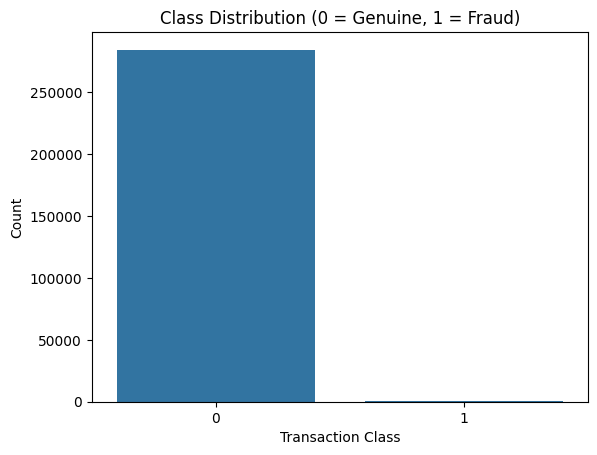

In [63]:
# Visual representation of class imbalance
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Genuine, 1 = Fraud)")
plt.xlabel("Transaction Class")
plt.ylabel("Count")
plt.show()


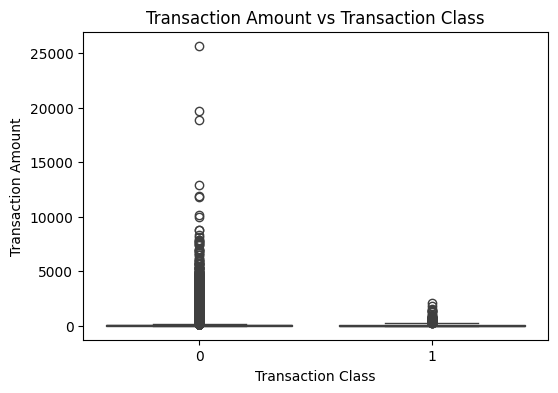

In [64]:
# Compare transaction amounts between fraud and genuine cases
plt.figure(figsize=(6, 4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount vs Transaction Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.show()


- Fraudulent transactions typically involve lower amounts.
- Some high-value fraud cases exist.

Conclusion: Amount alone is not sufficient for fraud detection.


#Data Cleaning & Preprocessing

In [65]:
# Initialize scaler to standardize numerical features
scaler = StandardScaler()

# Scale Time and Amount features
# Other features (V1–V28) are already PCA-transformed
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])
#Brings features to a common scale

In [66]:
# Separate input features (X) and target variable (y)
X = df.drop('Class', axis=1)
y = df['Class']
#Prevents accidental data leakage

In [67]:
# Split data into training and testing sets
# Stratification preserves class imbalance ratio
#Both training and test sets contain fraud samples.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

Logistic Regression
-using it as it is interpretable and performs well on linearly separable data.

In [68]:
# Initialize Logistic Regression with class balancing
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

# Train the model on training data
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [69]:
# Predict fraud labels on test data
y_pred = log_model.predict(X_test)

# Display precision, recall, and F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443



In [70]:
# Predict probabilities for ROC-AUC calculation
y_prob = log_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9679721649664201


ROC-AUC measures the model’s ability to distinguish between classes
independent of classification threshold.


Decision Tree

In [71]:
# Initialize Decision Tree with controlled complexity
dt_model = DecisionTreeClassifier(
    max_depth=5,          # Maximum depth to prevent overfitting
    min_samples_split=50, # Minimum samples required to split a node
    random_state=42       # Ensures reproducible results
)


In [72]:
# Fit the model on training data
dt_model.fit(X_train, y_train)

# Predict probabilities for ROC-AUC evaluation
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

# Predict class labels for confusion matrix
y_pred_class = dt_model.predict(X_test)


In [73]:
# Compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

# Detailed classification metrics
report = classification_report(y_test, y_pred_class)

# Display results
print(f"Decision Tree ROC-AUC: {roc_auc:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", report)


Decision Tree ROC-AUC: 0.9086

Confusion Matrix:
 [[85278    17]
 [   41   107]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.72      0.79       148

    accuracy                           1.00     85443
   macro avg       0.93      0.86      0.89     85443
weighted avg       1.00      1.00      1.00     85443



ROC-AUC: Measures the ability to rank fraud vs genuine transactions across all thresholds.

Confusion Matrix & Classification Report: Focus on recall for fraudulent transactions (Class 1). Missing frauds = real-world risk.

Model Complexity: max_depth and min_samples_split help prevent overfitting due to imbalanced classes.

Decision Trees: Can capture non-linear relationships missed by Logistic Regression.

Decision Tree can detect complex fraud patterns better than a simple linear model.

High ROC-AUC doesn’t guarantee high recall—always check Class 1 metrics.

Depth and split constraints are crucial to avoid overfitting.

Comparison with Logistic Regression will reveal whether the tree improves fraud detection without too many false alarms.